<a href="https://colab.research.google.com/github/PavaniSriBhuviPamidimukkala/Alfido-Tech-Internship/blob/main/DeepVision_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [3]:
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [5]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_datagen.fit(x_train)

In [7]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

/tmp/ipykernel_12939/1419623657.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history = model.fit(
    train_datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - accuracy: 0.2550 - loss: 2.0461 - val_accuracy: 0.3075 - val_loss: 1.9380
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - accuracy: 0.2836 - loss: 1.9572 - val_accuracy: 0.3192 - val_loss: 1.9031
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.2958 - loss: 1.9434 - val_accuracy: 0.3230 - val_loss: 1.8835
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 95ms/step - accuracy: 0.2975 - loss: 1.9302 - val_accuracy: 0.3296 - val_loss: 1.8725
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.3002 - loss: 1.9240 - val_accuracy: 0.3252 - val_loss: 1.8655
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 95ms/step - accuracy: 0.3016 - loss: 1.9207 - val_accuracy: 0.3291 - val_loss: 1.8578
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.3021 - loss: 1.9144 - val_accuracy: 0.3370 - val_loss: 1.8468
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.3066 - loss: 1.9073 -

In [12]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3441 - loss: 1.8331
Test Loss: 1.8330659866333008
Test Accuracy: 0.3440999984741211


In [13]:
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step


In [14]:
print(classification_report(true_classes, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.36      0.45      0.40      1000
  Automobile       0.34      0.31      0.33      1000
        Bird       0.31      0.11      0.16      1000
         Cat       0.34      0.23      0.28      1000
        Deer       0.42      0.33      0.37      1000
         Dog       0.26      0.39      0.31      1000
        Frog       0.42      0.47      0.44      1000
       Horse       0.36      0.34      0.35      1000
        Ship       0.34      0.29      0.31      1000
       Truck       0.32      0.52      0.40      1000

    accuracy                           0.34     10000
   macro avg       0.35      0.34      0.33     10000
weighted avg       0.35      0.34      0.33     10000



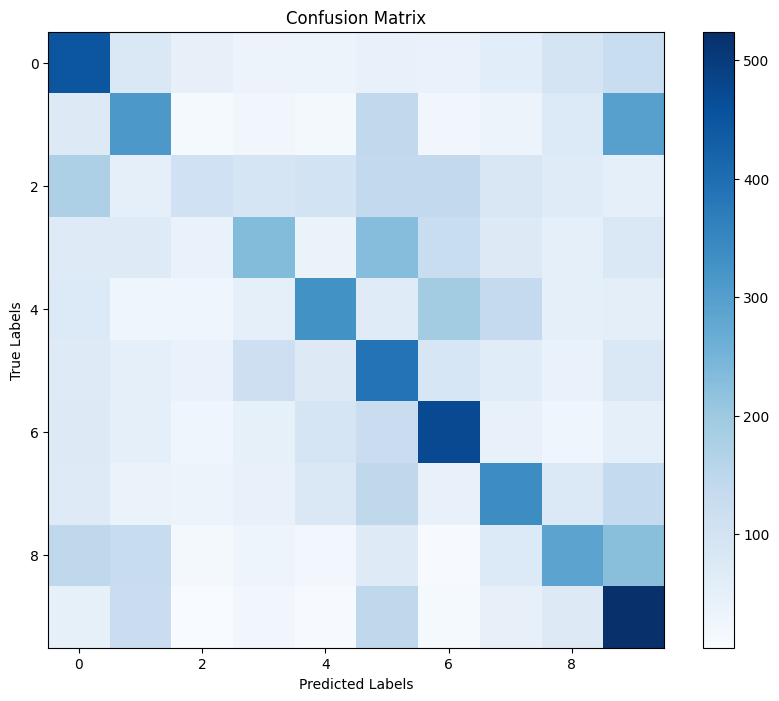

In [15]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

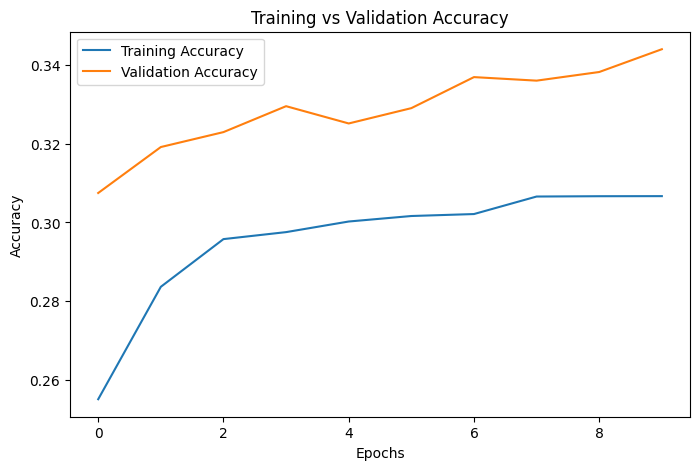

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

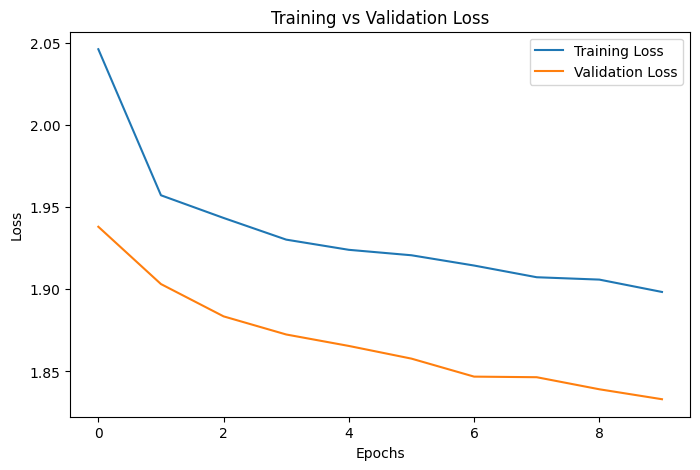

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
model.save('image_classifier_model.h5')

print("Model saved successfully!")

Model saved successfully!


In [19]:
loaded_model = tf.keras.models.load_model('image_classifier_model.h5')

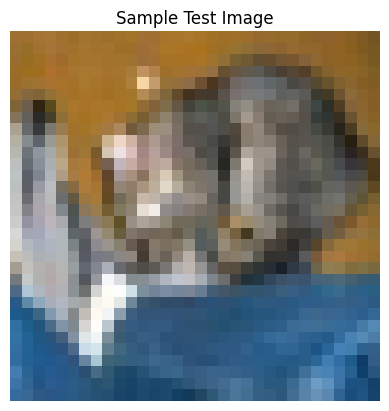

In [20]:
sample_image = x_test[0]

plt.imshow(sample_image)
plt.title("Sample Test Image")
plt.axis('off')
plt.show()

In [21]:
sample_image_expanded = np.expand_dims(sample_image, axis=0)

prediction = loaded_model.predict(sample_image_expanded)
predicted_label = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: Truck


In [22]:
from google.colab import files

files.download('image_classifier_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>